# 09 — Bridgewater All Weather-style risk balancing

## 🧭 tl;dr

Bridgewater's public All Weather story is associated with balancing portfolio risk across growth and inflation environments. This notebook tests a simple four-asset risk-balanced proxy against equal weight, a 60/40 control, and SPY. It is not Bridgewater's proprietary All Weather portfolio.

> Educational research only. This notebook is not investment advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Start with the assumptions, then follow the data and rule definitions. The tables and charts report the formal test period. Finish with <strong>What went well / what went wrong</strong> — that is where the research judgment and limitations are made explicit.
</div>


## 🧭 Context & methods

Risk parity asks how much risk each asset contributes, rather than simply how many dollars each asset receives. A simple inverse-volatility portfolio gives smaller weights to assets with higher recent volatility. It is a useful teaching approximation, but true institutional risk parity also models correlations, expected returns, leverage, financing, and a much broader opportunity set.

### Key assumptions

- `SPY` represents growth-sensitive equities, `TLT` duration, `GLD` a precious-metal inflation hedge, and `DBC` a broad commodity proxy.
- The risk-balanced proxy re-estimates inverse-volatility weights monthly from the prior 60 trading days.
- Adjusted daily closes, a one-bar execution delay, 10 bps per unit of weight turnover, and an untouched final 20% test period are used.
- The 60/40 control is 60% SPY and 40% TLT; unused weight is not leveraged.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import equal_weight_weights, inverse_volatility_weights, run_portfolio_backtest
from src.research import comparison_table, metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data and portfolio definitions

The sample starts in 2006 so the common history includes the commodity proxy. The portfolio is deliberately small and liquid enough for a beginner to inspect.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['SPY', 'TLT', 'GLD', 'DBC']

if USE_DEMO_DATA:
    close = pd.concat([make_demo_ohlcv(periods=5_000, seed=i + 20, start='2006-01-01')['close'].rename(t) for i, t in enumerate(TICKERS)], axis=1)
else:
    try:
        close = load_price_panel(TICKERS, '2006-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat([make_demo_ohlcv(periods=5_000, seed=i + 20, start='2006-01-01')['close'].rename(t) for i, t in enumerate(TICKERS)], axis=1)

splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
sixty_forty = pd.DataFrame(0.0, index=close.index, columns=close.columns)
sixty_forty['SPY'] = 0.60
sixty_forty['TLT'] = 0.40
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')

Data: 2006-02-06 through 2025-12-31 (5,008 common trading days)


## Public source and translation

Bridgewater's [All Weather story](https://www.bridgewater.com/research-and-insights/the-all-weather-story) describes a portfolio designed to remain balanced across uncertain growth and inflation outcomes. The notebook translates that idea into a simple four-asset, inverse-volatility ETF proxy. The translation omits Bridgewater's economic scenario mapping, leverage, derivatives, financing, correlation model, and broader instrument universe.

In [3]:
weights = {
    'Equal-weight control': equal_weight_weights(close),
    '60/40 control': sixty_forty,
    'All Weather inverse-volatility proxy': inverse_volatility_weights(close, lookback=60),
}
results = {
    name: run_portfolio_backtest(
        close, target_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    for name, target_weights in weights.items()
}

test_table = comparison_table(results, splits['test'].index)
test_table.style.format({
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}', 'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}', 'annualized_turnover': '{:.2f}', 'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}', 'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Equal-weight control,8.27%,10.56%,0.81,1.18,-18.00%,0.46,54.89%,0.00,0,37.15%,0.509089,-13.75%
60/40 control,3.26%,13.19%,0.31,0.44,-26.24%,0.12,52.69%,0.00,0,13.61%,0.509089,-37.30%
All Weather inverse-volatility proxy,7.17%,10.38%,0.72,1.05,-20.04%,0.36,53.99%,0.99,48,31.71%,0.509089,-19.20%


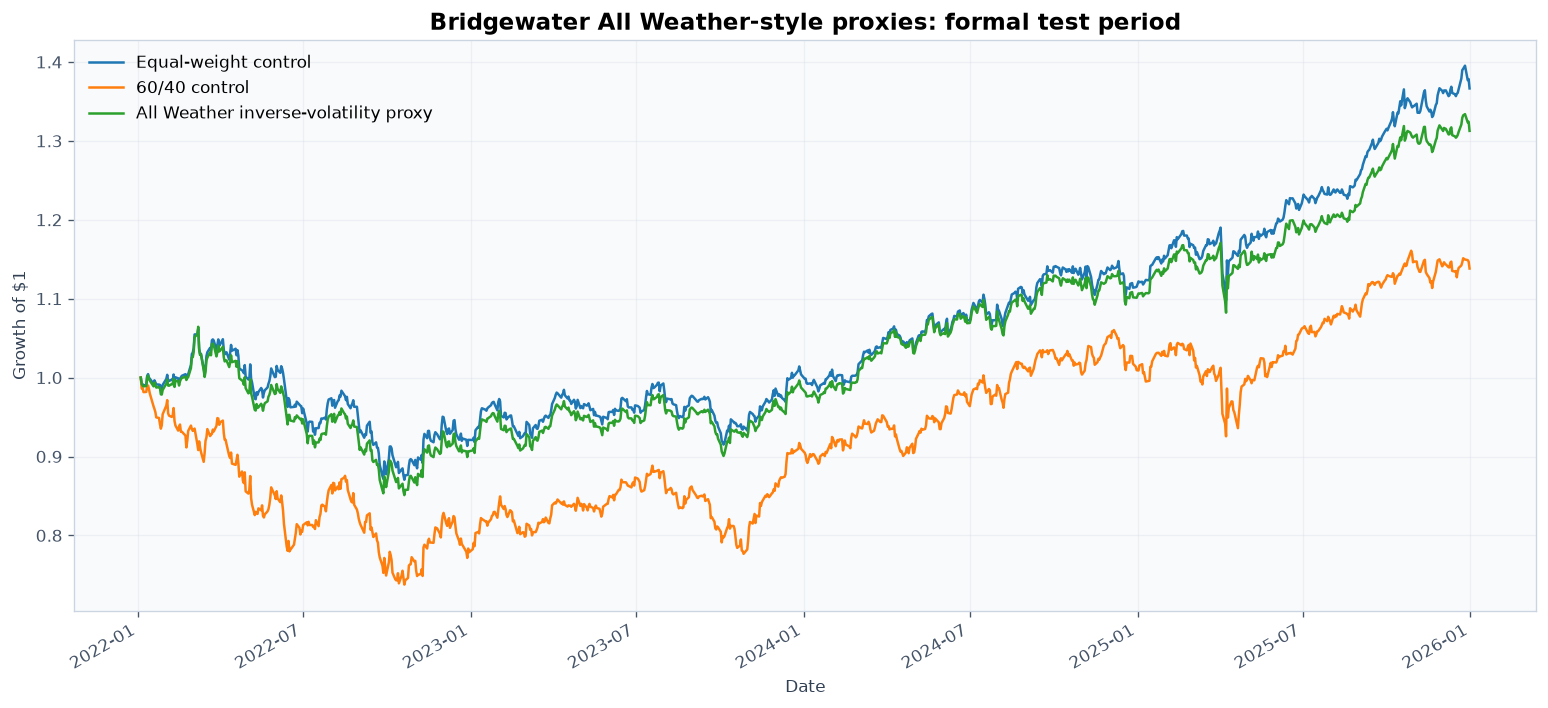

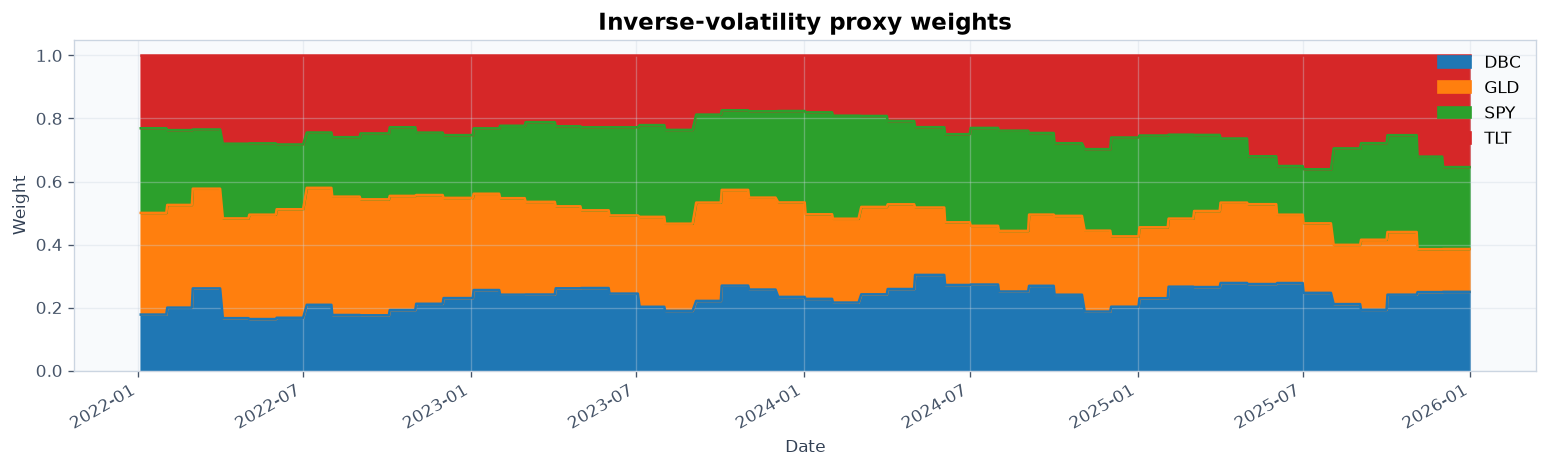

In [4]:
ax = None
for name, result in results.items():
    equity = result.frame['equity'].loc[splits['test'].index]
    ax = (equity / equity.iloc[0]).plot(ax=ax, figsize=(13, 6), label=name)
ax.set_title('Bridgewater All Weather-style proxies: formal test period')
ax.set_ylabel('Growth of $1')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

results['All Weather inverse-volatility proxy'].held_weights.loc[splits['test'].index].plot.area(figsize=(13, 4), title='Inverse-volatility proxy weights')
plt.ylabel('Weight')
plt.show()

## 🛡️ Stress-window diagnostics

These windows are descriptive. A portfolio that protects in one crisis may fail when the inflation, rates, and equity relationships change.

In [5]:
stress_windows = {
    'Global Financial Crisis': ('2007-10-01', '2009-03-31'),
    'COVID shock': ('2020-02-19', '2020-03-23'),
    '2022 inflation/rates shock': ('2022-01-03', '2022-10-14'),
}
rows = []
for window, (start, end) in stress_windows.items():
    index = close.loc[start:end].index
    for name, result in results.items():
        returns = result.frame.loc[index, 'net_returns']
        equity = (1.0 + returns).cumprod()
        rows.append({'window': window, 'strategy': name, 'return': equity.iloc[-1] - 1.0 if len(equity) else float('nan'), 'max_drawdown': (equity / equity.cummax() - 1.0).min() if len(equity) else float('nan')})
stress_table = pd.DataFrame(rows)
stress_table.style.format({'return': '{:.2%}', 'max_drawdown': '{:.2%}'})

,window,strategy,return,max_drawdown
0,Global Financial Crisis,Equal-weight control,-6.62%,-27.56%
1,Global Financial Crisis,60/40 control,-20.54%,-29.92%
2,Global Financial Crisis,All Weather inverse-volatility proxy,4.03%,-19.21%
3,COVID shock,Equal-weight control,-12.82%,-16.50%
4,COVID shock,60/40 control,-16.02%,-17.76%
5,COVID shock,All Weather inverse-volatility proxy,-12.25%,-16.33%
6,2022 inflation/rates shock,Equal-weight control,-12.47%,-17.91%
7,2022 inflation/rates shock,60/40 control,-26.73%,-26.21%
8,2022 inflation/rates shock,All Weather inverse-volatility proxy,-14.45%,-19.83%


In [6]:
best_sharpe = test_table['sharpe_ratio'].idxmax()
lowest_drawdown = test_table['max_drawdown'].idxmax()
print('Finding:', best_sharpe, 'had the highest test Sharpe', round(float(test_table.loc[best_sharpe, 'sharpe_ratio']), 2))
print('Finding:', lowest_drawdown, 'had the shallowest test drawdown', round(float(test_table.loc[lowest_drawdown, 'max_drawdown']) * 100, 2), 'percent')
print('The key question is whether lower risk came from better diversification or simply lower equity exposure.')

Finding: Equal-weight control had the highest test Sharpe 0.81
Finding: Equal-weight control had the shallowest test drawdown -18.0 percent
The key question is whether lower risk came from better diversification or simply lower equity exposure.


## ⚖️ What went well / what went wrong

**What went well:** The risk-balanced proxy forces the analysis to look beyond a stock-only portfolio. Bonds, gold, and commodities can contribute different exposures, and inverse volatility often reduces concentration in the most volatile asset.

**What went wrong:** Correlations can rise together during stress, long-duration bonds can lose money when inflation and rates rise, and commodities can be volatile or structurally costly to hold. Inverse volatility is only a rough risk-parity approximation; it ignores covariance, leverage, financing, taxes, futures rolls, and the actual All Weather implementation. It may also lag SPY during a long equity bull market.

**Beginner takeaway:** Diversification is not the same as protection. Ask which economic risk each asset is meant to offset, then check whether that relationship actually held in the stress window.